In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 15

In [3]:
TRAIN_DIR = r"C:\Users\YOGA\Documents\DATASET\CAPSTONE_SPLIT\train"
VAL_DIR = r"C:\Users\YOGA\Documents\DATASET\CAPSTONE_SPLIT\val"
TEST_DIR = r"C:\Users\YOGA\Documents\DATASET\CAPSTONE_SPLIT\test"


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.1)
])

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.1)
])

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 4913 images belonging to 2 classes.


In [8]:
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


Found 1065 images belonging to 2 classes.


In [9]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1062 images belonging to 2 classes.


In [10]:
# Load base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [11]:
# BUILD MODEL

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 1,693,057 (6.46 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [13]:
callbacks = [
EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
),

ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3
),

ModelCheckpoint(
    "best_clean_dirty_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)]

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9925252525252525), 1: np.float64(1.0075881870385561)}


In [15]:
# TRAIN MODEL (STAGE 1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/15
44/77 ━━━━━━━━━━━━━━━━━━━━ 1:10 2s/step - accuracy: 0.6115 - loss: 0.7460 - precision: 0.6129 - recall: 0.6675

c:\Users\YOGA\Documents\Pythonnn\tf_env\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


77/77 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.6762 - loss: 0.6240 - precision: 0.6574 - recall: 0.7256 - val_accuracy: 0.8488 - val_loss: 0.3840 - val_precision: 0.9022 - val_recall: 0.7763 - learning_rate: 1.0000e-05
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.8030 - loss: 0.4344 - precision: 0.7954 - recall: 0.8117 - val_accuracy: 0.8798 - val_loss: 0.3003 - val_precision: 0.9519 - val_recall: 0.7954 - learning_rate: 1.0000e-05
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.8512 - loss: 0.3477 - precision: 0.8502 - recall: 0.8499 - val_accuracy: 0.8930 - val_loss: 0.2686 - val_precision: 0.9616 - val_recall: 0.8145 - learning_rate: 1.0000e-05
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.8754 - loss: 0.2989 - precision: 0.8785 - recall: 0.8692 - val_accuracy: 0.8958 - val_loss: 0.2545 - val_precision: 0.9619 - val_recall: 0.8203 - learning_rate: 1.0000e-05
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 

In [17]:
# FINE-TUNING


base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9560 - loss: 0.1143 - val_accuracy: 0.9596 - val_loss: 0.1181 - learning_rate: 1.0000e-05
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9564 - loss: 0.1173 - val_accuracy: 0.9624 - val_loss: 0.1262 - learning_rate: 1.0000e-05
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.9550 - loss: 0.1154 - val_accuracy: 0.9634 - val_loss: 0.1162 - learning_rate: 1.0000e-05
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.9573 - loss: 0.1109 - val_accuracy: 0.9596 - val_loss: 0.1314 - learning_rate: 1.0000e-05
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.9621 - loss: 0.1057 - val_accuracy: 0.9615 - val_loss: 0.1233 - learning_rate: 1.0000e-05
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.9544 - loss: 0.1168 - val_accuracy: 0.9624 - val_loss: 0.1235 - learning_rate: 1.0000e-05
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9607 

In [18]:
# TEST MODEL
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9736 - loss: 0.0891
Test Accuracy: 0.973634660243988


In [19]:
model.save("RURALOPS2.keras")
print("Model saved successfully")

Model saved successfully


In [20]:
history.history

{'accuracy': [0.6761652827262878,
  0.8029717206954956,
  0.8512110710144043,
  0.875432550907135,
  0.8951760530471802,
  0.8963972926139832,
  0.9043354392051697,
  0.9132912755012512,
  0.9143089652061462,
  0.9240790009498596,
  0.9248931407928467,
  0.9259108304977417,
  0.9303887486457825,
  0.9377162456512451,
  0.9314064979553223],
 'loss': [0.6240013837814331,
  0.43444597721099854,
  0.3477311432361603,
  0.2989162802696228,
  0.2656416594982147,
  0.2465730607509613,
  0.24282008409500122,
  0.21953698992729187,
  0.21423238515853882,
  0.19747911393642426,
  0.18829098343849182,
  0.18455559015274048,
  0.17841742932796478,
  0.165415421128273,
  0.17814691364765167],
 'precision': [0.6573764681816101,
  0.7954180240631104,
  0.8502256870269775,
  0.8785240650177002,
  0.8987971544265747,
  0.9071338176727295,
  0.9103419780731201,
  0.9163907170295715,
  0.9189862608909607,
  0.926124632358551,
  0.9283643960952759,
  0.9274526238441467,
  0.9348547458648682,
  0.939044475

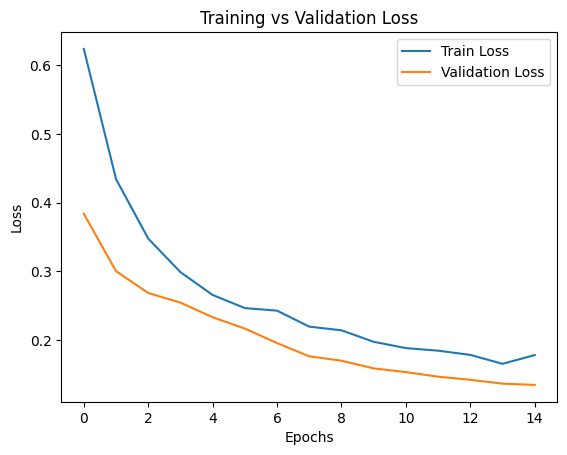

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

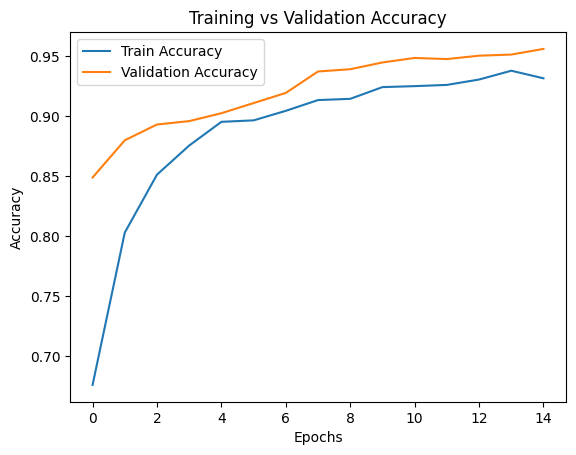

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()